## **Heat Forecast Comparisions**

- **Data**: heat_demand 
- **Models**: Persistence, SARIMA, XGBoost and  LSTM(with different preprocessors and hyperparameters).

### **Setup: path, imports, load data**

In [1]:
from pathlib import Path
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import sys
# Project root = folder that contains Data/ (and preprocessor/, forecast_models/)
ROOT = Path.cwd() if (Path.cwd() / "Data").exists() else Path.cwd().parent
if not (ROOT / "Data").exists():
    raise FileNotFoundError("Data folder not found. Run notebook from project root or forecast_implementation.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
from forecast_implementation.forecast_helper import compare_models_on_test, evaluate_model, evaluate_model_rolling, run_pipelines_hyperparam_rolling, run_pipelines_hyperparam, rmse, mape, r2, set_seed,mbe,best_model_test_forecast,get_test_forecast,format_for_csv
from preprocessor import *
from forecast_models import *

In [2]:
SAVE = True

In [3]:
set_seed(42)

In [4]:
DATA_DIR = ROOT / "Data"
gas_elec_raw = pd.read_csv(DATA_DIR / "gas_electricity_hourly.csv", index_col=0, parse_dates=True)

In [5]:
splitter = get_date_splitter("electricity", config_path=ROOT / "split_config.csv")

In [6]:
gas_elec_raw.head()

,elecmeter,gasmeter
2024-01-01 00:00:00,6.736869,114.93
2024-01-01 01:00:00,5.390000,90.00
2024-01-01 02:00:00,5.149623,104.03
2024-01-01 03:00:00,6.573508,112.97
2024-01-01 04:00:00,5.140000,103.07


In [7]:
# our electricity data frame
df_heat = gas_elec_raw[['gasmeter']]
series_heat = df_heat['gasmeter']
df_heat.head()

,gasmeter
2024-01-01 00:00:00,114.93
2024-01-01 01:00:00,90.00
2024-01-01 02:00:00,104.03
2024-01-01 03:00:00,112.97
2024-01-01 04:00:00,103.07


In [8]:
# Add temperature from Open-Meteo (WeatherFeatures) for SARIMAX / exog use
# Lat/lon: Kiel, Germany (adjust if your data is from elsewhere)
weather = WeatherFeatures(latitude=54.322933, longitude=9.615820, variables=["temperature_2m"]) # Büsumer Straße 135-137, 24768 Rendsburg, Germany
weather.fit(df_heat)
df_heat_temp = weather.transform(df_heat).rename(columns={"temperature_2m": "temperature"})
df_heat_temp.head()

,gasmeter,temperature
2024-01-01 00:00:00,114.93,5.5
2024-01-01 01:00:00,90.00,5.5
2024-01-01 02:00:00,104.03,5.3
2024-01-01 03:00:00,112.97,5.4
2024-01-01 04:00:00,103.07,5.2


In [9]:
df_heat_temp.corr()

,gasmeter,temperature
gasmeter,1.000000,-0.834722
temperature,-0.834722,1.000000


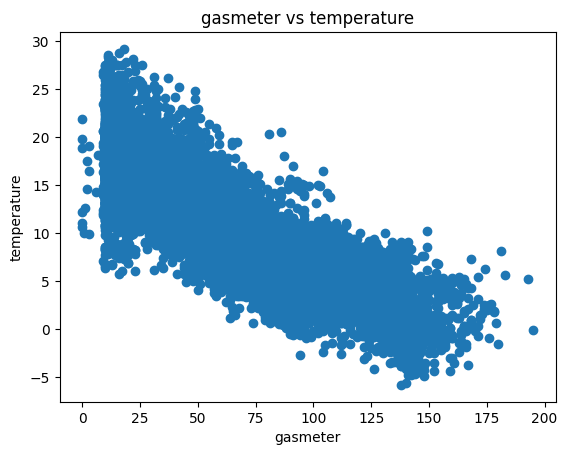

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df_heat_temp["gasmeter"], df_heat_temp["temperature"])
plt.xlabel("gasmeter")
plt.ylabel("temperature")
plt.title("gasmeter vs temperature")
plt.show()

### **Persistence Model**

In [11]:
pipelines_persistence = [
    {"model_type": "forecast", 
    "preprocessing": [], 
    "splitter": splitter,
     "model": lambda **kw: PersistenceModel(period=24), 
     "hyperparams": {}}]

In [12]:
results_persistence, best_hp_persistence, best_prep_persistence = run_pipelines_hyperparam(df_heat, pipelines_persistence, {"rmse":rmse,"mbe":mbe})


Running pipeline 1


In [13]:
results_persistence

,pipeline_idx,preprocessing,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,1,,14.102069,-3.651259,0.000226,10.192526,0.022544


### **SARIMA Model**

In [14]:
def generate_order_combinations(p_range, d_range, q_range):
    return list(itertools.product(p_range, d_range, q_range))

In [15]:
pipeline1 = {
    "model_type": "forecast",
    "preprocessing": [LogTransform()],
    "splitter": splitter,
    "model": SARIMA_Model,
    "hyperparams": {
        "order": [(p,d,q) for p,d,q in generate_order_combinations(range(0,2), range(0,2), range(0,2))],#[(1,0,0), (2,0,0),(1,1,0)],#
        "seasonal_order": [(1,0,0,24), (0,0,1,24), (1,0,1,24)]
    }
}

pipeline2 = {
    "model_type": "forecast",
    "preprocessing": [],
    "splitter": splitter,
    "model": SARIMA_Model,
    "hyperparams": {
        "order": [(p,d,q) for p,d,q in generate_order_combinations(range(0,2), range(0,2), range(0,2))],#[(1,0,0), (2,0,0),(1,1,0)],#
        "seasonal_order": [(1,0,0,24), (0,0,1,24), (1,0,1,24)]  # (2,0,1,24) removed: MemoryError
    }
}

pipeline_sarimax = {
    "model_type": "forecast",
    "preprocessing": [],  
    "splitter": splitter,
    "model": SARIMAX_Model,
    "hyperparams": {
        "order": [(p,d,q) for p,d,q in generate_order_combinations(range(0,2), range(0,2), range(0,2))],#[(1,0,0), (2,0,0),(1,1,0)],#
        "seasonal_order": [(1, 0, 1, 24)],
        "exog_col": ["temperature"],   
        "target_col": ["elecmeter"],   
    },
}

_orders_simple = [(0,0,0), (1,0,0), (0,0,1), (1,0,1)]
_seasonal_simple = [(p,d,q,24) for p,d,q in generate_order_combinations(range(0,2), range(0,2), range(0,2))]

pipeline1 = {
    "model_type": "forecast",
    "preprocessing": [LogTransform()],
    "splitter": splitter,
    "model": SARIMA_Model,
    "hyperparams": {"order": _orders_simple, "seasonal_order": _seasonal_simple}
}

pipeline2 = {
    "model_type": "forecast",
    "preprocessing": [],
    "splitter": splitter,
    "model": SARIMA_Model,
    "hyperparams": {"order": _orders_simple, "seasonal_order": _seasonal_simple}
}



sarima_piplines = [pipeline1, pipeline2]

In [16]:
results_SARIMA, best_hp_sarima, best_prep_sarima = run_pipelines_hyperparam(series_heat, sarima_piplines, {"rmse":rmse,"mbe":mbe})


Running pipeline 1

Running pipeline 2


In [17]:
results_SARIMA.sort_values("rmse", ascending=True, inplace=True)

In [18]:
results_SARIMA.head()

,pipeline_idx,preprocessing,order,seasonal_order,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,1,LogTransform,"(1, 0, 0)","(1, 1, 1, 24)",12.108177,-1.188375,5.552301,15.648471,0.356207
1,2,,"(0, 0, 1)","(1, 1, 1, 24)",12.118587,-0.656487,4.856685,13.983247,0.905700
2,2,,"(0, 0, 0)","(1, 1, 1, 24)",12.190959,-0.684293,4.100394,15.239660,1.303242
3,1,LogTransform,"(1, 0, 0)","(0, 1, 1, 24)",12.223993,-1.943650,2.818314,14.617287,-0.164017
4,1,LogTransform,"(1, 0, 1)","(0, 1, 1, 24)",12.344979,2.550819,9.597275,176.474855,2.484901


In [19]:
best_hp_sarima

{'order': (1, 0, 0), 'seasonal_order': (1, 1, 1, 24)}

In [20]:
format_for_csv(results_SARIMA.head().drop("preprocessing",axis=1)).sort_values("rmse")

,pipeline_idx,order,seasonal_order,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,1,"(1, 0, 0)","(1, 1, 1, 24)",12.11,-1.19,5.55,15.65,0.36
1,2,"(0, 0, 1)","(1, 1, 1, 24)",12.12,-0.66,4.86,13.98,0.91
2,2,"(0, 0, 0)","(1, 1, 1, 24)",12.19,-0.68,4.10,15.24,1.30
3,1,"(1, 0, 0)","(0, 1, 1, 24)",12.22,-1.94,2.82,14.62,-0.16
4,1,"(1, 0, 1)","(0, 1, 1, 24)",12.34,2.55,9.60,176.47,2.48


In [21]:
if SAVE:
    format_for_csv(results_SARIMA.head().drop("preprocessing",axis=1)).sort_values("rmse").to_csv(DATA_DIR/"heat_SARIMA_Summary.csv",index=False)

In [22]:
pipeline_sarimax = {
    "model_type": "forecast",
    "preprocessing": [],  
    "splitter": splitter,
    "model": SARIMAX_Model,
    "hyperparams": {
        "order": [best_hp_sarima['order']],
        "seasonal_order": [best_hp_sarima['seasonal_order']],
        "exog_col": ["temperature"],   
        "target_col": ["gasmeter"],   
    },
}

In [23]:
results_SARIMAX, best_hp_sarimax, best_prep_sarimax = run_pipelines_hyperparam(df_heat_temp, [pipeline_sarimax], {"rmse":rmse,"mbe":mbe})


Running pipeline 1


In [24]:
def sarima_test_residuals_with_preproc(series, pipelines, best_hp):
    # Assume a single SARIMA pipeline in this list
    pipe = pipelines[0]
    splitter = pipe["splitter"]
    preprocessors = pipe.get("preprocessing", [])
    # 1) Split as in the comparison
    train_df, val_df, test_df = splitter(series)
    # 2) Apply preprocessors (fit on train, transform train/val/test)
    train, val, test = train_df.copy(), val_df.copy(), test_df.copy()
    for step in preprocessors:
        step.fit(train)
        train = step.transform(train)
        val = step.transform(val)
        test = step.transform(test)
    # 3) Fit SARIMA on preprocessed train
    model = pipe["model"](**best_hp)   # SARIMA_Model(order=..., seasonal_order=...)
    model.fit(train)
    # 4) Forecast over preprocessed TEST horizon
    horizon = len(test)
    y_pred = model.predict(horizon)
    # Ensure 1D array
    y_pred = np.asarray(y_pred).squeeze()
    # 5) Invert preprocessors on predictions (same order as in evaluate_model)
    for step in reversed(preprocessors):
        if hasattr(step, "inverse"):
            y_pred = step.inverse(y_pred)
    # 6) y_true on original scale = original (untransformed) test_df
    y_true = test_df.squeeze()
    y_pred = pd.Series(y_pred, index=test_df.index)
    residuals = y_true - y_pred
    return pd.DataFrame(
        {"y_true": y_true, "y_pred": y_pred, "residual": residuals},
        index=test_df.index,
    )
sarima_test_df = sarima_test_residuals_with_preproc(series_heat, sarima_piplines, best_hp_sarima)
sarima_test_df.head()

,y_true,y_pred,residual
2024-10-01 00:00:00,46.0,24.360554,21.639446
2024-10-01 01:00:00,46.0,22.004355,23.995645
2024-10-01 02:00:00,46.0,16.844271,29.155729
2024-10-01 03:00:00,45.0,19.649962,25.350038
2024-10-01 04:00:00,46.0,20.703936,25.296064


Shapiro–Wilk p-value: 1.3458176343509012e-17


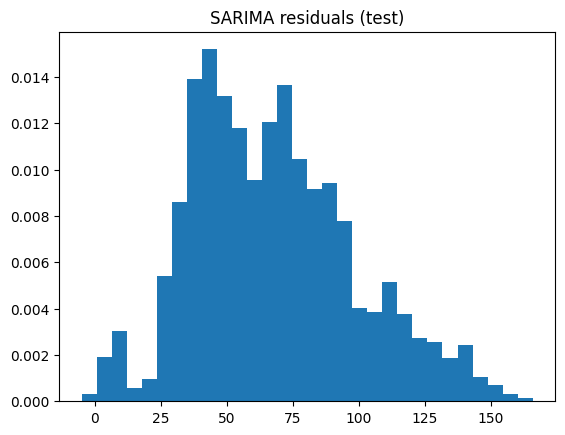

<Figure size 640x480 with 0 Axes>

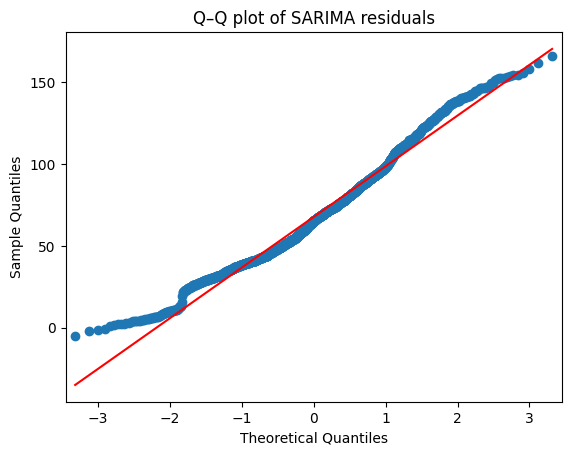

In [25]:
resid = sarima_test_df["residual"].dropna()
# Histogram
plt.figure()
plt.hist(resid, bins=30, density=True)
plt.title("SARIMA residuals (test)")
# Q-Q plot
plt.figure()
sm.qqplot(resid, line="s")
plt.title("Q–Q plot of SARIMA residuals")
sw_stat, sw_p = stats.shapiro(resid)
print("Shapiro–Wilk p-value:", sw_p)

In [26]:
results_SARIMAX.sort_values("rmse", ascending=True, inplace=True)
results_SARIMAX

,pipeline_idx,preprocessing,order,seasonal_order,exog_col,target_col,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,1,,"(1, 0, 0)","(1, 1, 1, 24)",temperature,gasmeter,12.423046,2.905113,13.590157,10.608354,0.835815


### **XgBoost Model**

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
import matplotlib.pyplot as plt

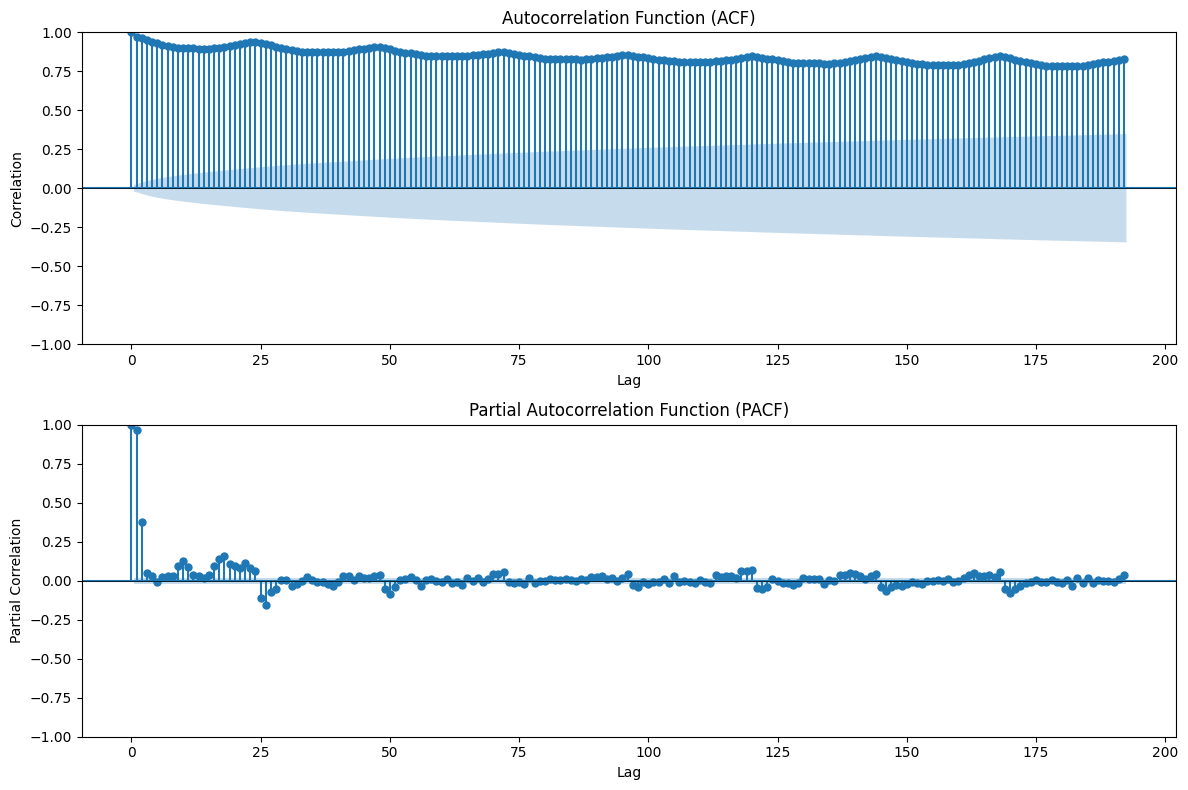

In [28]:
# Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# ACF plot
plot_acf(df_heat['gasmeter'], ax=ax1, lags=192, alpha=0.05)
ax1.set_title('Autocorrelation Function (ACF)')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Correlation')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# PACF plot
plot_pacf(df_heat['gasmeter'], ax=ax2, lags=192, alpha=0.05, method='ywm')
ax2.set_title('Partial Autocorrelation Function (PACF)')
ax2.set_xlabel('Lag')
ax2.set_ylabel('Partial Correlation')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

In [29]:
target_col = "gasmeter"
pipeline_1_xg = {"model_type": "tabular", 
"target_col": target_col,
"preprocessing": [Standardize(), 
                LagFeatures(target_col=target_col, lags=[1] + [12 * i for i in range(1, 14+1)]),
                WeatherFeatures(latitude=54.322933, longitude=9.615820, variables=["temperature_2m"]),
                CalendarFeatures(features=["hour", "dayofweek", "month"], cyclical=True),
                GermanHoliday(subdiv="SH")],
"splitter":splitter,
"model": lambda **kw: XGBModel(**kw), 
"hyperparams": {"n_estimators": [50, 100], "max_depth": [3, 6]}}

pipeline_2_xg = {"model_type": "tabular", 
"target_col": target_col,
"preprocessing": [LagFeatures(target_col=target_col, lags=[1] + [12 * i for i in range(1, 14+1)])],
"splitter":splitter,
"model": lambda **kw: XGBModel(**kw), 
"hyperparams": {"n_estimators": [50, 100], "max_depth": [3, 6]}}

xgboost_pipelines = [pipeline_1_xg, pipeline_2_xg]

In [30]:
results_xgboost, best_hp_xgboost, best_prep_xgboost = run_pipelines_hyperparam(df_heat, xgboost_pipelines, {"rmse":rmse,"mbe":mbe})


Running pipeline 1

Running pipeline 2


In [31]:
results_xgboost.sort_values("rmse", ascending=True).head()

,pipeline_idx,preprocessing,n_estimators,max_depth,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,2,LagFeatures,100,3,7.602954,1.211026,0.076452,6.867673,0.000461
1,2,LagFeatures,50,3,7.640121,1.835584,0.043885,7.669322,-0.000484
2,1,Standardize + LagFeatures + WeatherFeatures + ...,50,3,7.897556,2.566692,0.110968,7.064586,-0.001327
3,2,LagFeatures,50,6,7.971494,0.762308,0.091453,4.395041,-0.000648
4,1,Standardize + LagFeatures + WeatherFeatures + ...,100,3,8.039482,2.227348,0.064952,6.267438,0.000190


In [32]:
format_for_csv(results_xgboost.head().drop("preprocessing",axis=1)).sort_values("rmse")

,pipeline_idx,n_estimators,max_depth,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,2,100,3,7.60,1.21,0.08,6.87,0.00
1,2,50,3,7.64,1.84,0.04,7.67,-0.00
2,1,50,3,7.90,2.57,0.11,7.06,-0.00
3,2,50,6,7.97,0.76,0.09,4.40,-0.00
4,1,100,3,8.04,2.23,0.06,6.27,0.00


In [33]:
if SAVE:
    format_for_csv(results_xgboost.head().drop("preprocessing",axis=1)).sort_values("rmse").to_csv(DATA_DIR/"heat_xgboost_Summary.csv",index=False)

In [34]:
from copy import deepcopy
pipelines = []
for n in range(1, 15):  # n from 1 to 12
    pipeline = {
        "model_type": "tabular",
        "target_col": target_col,
        "preprocessing": [
            LagFeatures(target_col=target_col, lags=[1] + [12 * i for i in range(1, n+1)]),
            WeatherFeatures(latitude=54.322933, longitude=9.615820, variables=["temperature_2m"]),
            CalendarFeatures(features=["hour", "dayofweek", "month"], cyclical=True),
                GermanHoliday(subdiv="SH")
        ],
        "splitter": splitter,
        "model": lambda **kw: XGBModel(**kw),
        "hyperparams": {"n_estimators": [100], "max_depth": [3]}
    }
    
    pipelines.append(deepcopy(pipeline))

In [35]:
results_xgboost2, best_hp_xgboost2, best_prep_xgboost2 = run_pipelines_hyperparam(df_heat, pipelines, {"rmse":rmse,"mbe":mbe})


Running pipeline 1

Running pipeline 2

Running pipeline 3

Running pipeline 4

Running pipeline 5

Running pipeline 6

Running pipeline 7

Running pipeline 8

Running pipeline 9

Running pipeline 10

Running pipeline 11

Running pipeline 12

Running pipeline 13

Running pipeline 14


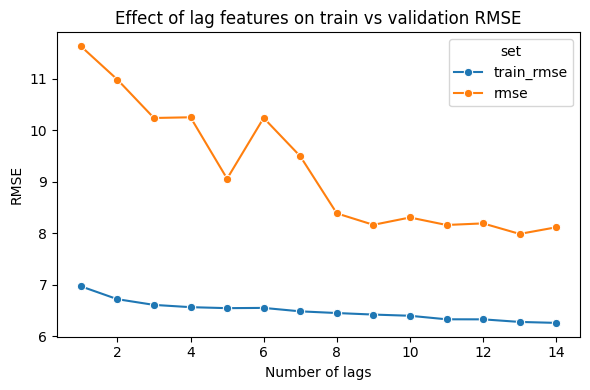

In [36]:
df = results_xgboost2.sort_values("pipeline_idx")
df["num_lags"] = df["pipeline_idx"].astype(int)
df_plot = df[["num_lags", "train_rmse", "rmse"]].sort_values("num_lags")
df_long = df_plot.melt(
    id_vars="num_lags",
    value_vars=["train_rmse", "rmse"],
    var_name="set",
    value_name="RMSE",
)
plt.figure(figsize=(6, 4))
sns.lineplot(
    data=df_long,
    x="num_lags",
    y="RMSE",
    hue="set",
    marker="o",
)
plt.xlabel("Number of lags")
plt.ylabel("RMSE")
plt.title("Effect of lag features on train vs validation RMSE")
plt.tight_layout()
plt.show()

### **LSTM Model**

In [37]:
preprocessors_lstm_e = [Standardize(), 
                LagFeatures(target_col=target_col, lags=[1, 2, 3, 24, 168]), 
                WeatherFeatures(latitude=54.322933, longitude=9.615820, variables=["temperature_2m"]),
                CalendarFeatures(features=["hour", "dayofweek", "month"], cyclical=True), 
                ReshapeToSequence(target_col=target_col, seq_len=24)]

def lstm_factory_elec(**kwargs):
    df_p = df_heat.copy()  # must be DataFrame so LagFeatures uses column 'elecmeter', not index
    for p in preprocessors_lstm_e:
        p.fit(df_p)
        df_p = p.transform(df_p)
    if isinstance(df_p, tuple):
        X, y = df_p
        return LSTM_Model(input_size=X.shape[2], **kwargs)
    return LSTM_Model(input_size=df_p.shape[1], **kwargs)

# pipeline_1_lstm = {"model_type": "tensor", 
#         "target_col": target_col,
#         "preprocessing": preprocessors_lstm_e, 
#         "splitter": TimeSeriesSplitter().transform,
#          "model": lstm_factory_elec, 
#          "hyperparams": {"hidden_size": [16, (16, 32), (16, 32, 12)], "epochs": [50,100], "patience": [5,15], "dropout": [0.1]}}

pipeline_1_lstm = {"model_type": "tensor", 
        "target_col": target_col,
        "preprocessing": preprocessors_lstm_e, 
        "splitter": splitter,
         "model": lstm_factory_elec, 
         "hyperparams": {"hidden_size": [16, 32],"num_layers":[2,4], "epochs": [50,100], "patience": [5,15], "dropout": [0.1],"lr":[0.001]}}



In [38]:
results_LSTM, best_hp_lstm, best_prep_lstm = run_pipelines_hyperparam(df_heat, [pipeline_1_lstm], {"rmse":rmse,"mbe":mbe})


Running pipeline 1


In [39]:
results_LSTM.sort_values("rmse", ascending=True).head()

,pipeline_idx,preprocessing,hidden_size,num_layers,epochs,patience,dropout,lr,rmse,mbe,elapsed_sec,train_rmse,train_mbe,history
0,1,Standardize + LagFeatures + WeatherFeatures + ...,16,2,50,15,0.1,0.001,8.945452,1.451321,10.677251,8.102989,-0.372868,"{'train_loss': [0.5109043758649092, 0.10312910..."
1,1,Standardize + LagFeatures + WeatherFeatures + ...,16,4,100,15,0.1,0.001,9.244488,1.759465,22.111661,7.749725,0.263376,"{'train_loss': [0.6273431658744812, 0.13212770..."
2,1,Standardize + LagFeatures + WeatherFeatures + ...,16,2,100,5,0.1,0.001,9.279907,4.222467,5.475708,8.414337,-0.100970,"{'train_loss': [0.46614790214942053, 0.1078290..."
3,1,Standardize + LagFeatures + WeatherFeatures + ...,16,2,50,5,0.1,0.001,9.388114,3.429924,2.777113,8.921898,0.665464,"{'train_loss': [0.5208133147313044, 0.10304188..."
4,1,Standardize + LagFeatures + WeatherFeatures + ...,16,2,100,15,0.1,0.001,9.430984,2.733868,13.608264,7.832735,0.144552,"{'train_loss': [0.45906914346493205, 0.1041814..."


In [40]:
format_for_csv(results_LSTM.head().drop(["preprocessing","history"],axis=1),decimal_places=3).sort_values("rmse")

,pipeline_idx,hidden_size,num_layers,epochs,patience,dropout,lr,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,1,16,2,50,15,0.100,0.001,8.945,1.451,10.677,8.103,-0.373
1,1,16,4,100,15,0.100,0.001,9.244,1.759,22.112,7.750,0.263
2,1,16,2,100,5,0.100,0.001,9.280,4.222,5.476,8.414,-0.101
3,1,16,2,50,5,0.100,0.001,9.388,3.430,2.777,8.922,0.665
4,1,16,2,100,15,0.100,0.001,9.431,2.734,13.608,7.833,0.145


In [41]:
if SAVE:
    format_for_csv(results_LSTM.head().drop(["preprocessing","history"],axis=1),decimal_places=3).sort_values("rmse").to_csv(DATA_DIR/"heat_lstm_Summary.csv",index=False)

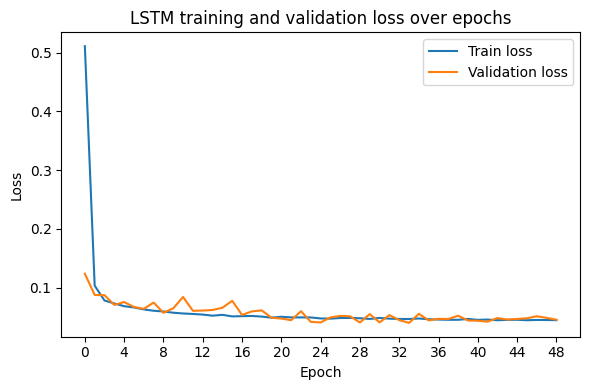

In [42]:
df_lstm = pd.DataFrame(results_LSTM.sort_values("rmse", ascending=True).history[0])
plt.figure(figsize=(6, 4))
plt.plot(df_lstm.index, df_lstm["train_loss"], label="Train loss")
plt.plot(df_lstm.index, df_lstm["val_loss"],   label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM training and validation loss over epochs")
plt.legend()
# Force integer epoch ticks
epochs = df_lstm.index.to_numpy()
plt.xticks(np.arange(0, len(df_lstm), 4))  # or np.arange(len(df_lstm)) if you prefer
plt.tight_layout()
plt.show()

### Compare all models on test set

Use the best hyperparameters from validation to evaluate each model once on the **test set** (RMSE and MBE).

In [33]:
# One entry per model: (name, data, pipelines_list, results_df, best_hyperparameters)
test_configs = [
    ("Persistence", df_heat, pipelines_persistence, results_persistence, best_hp_persistence),
    ("SARIMA", series_heat, sarima_piplines, results_SARIMA, best_hp_sarima),
    ("XGBoost", df_heat, xgboost_pipelines, results_xgboost, best_hp_xgboost),
    ("LSTM", df_heat, [pipeline_1_lstm], results_LSTM, best_hp_lstm),
]
test_metrics = {"rmse": rmse, "mbe": mbe}
comparison_test = compare_models_on_test(test_configs, metric_fn=test_metrics)
comparison_test

,model,rmse,mbe,elapsed_sec,train_rmse,train_mbe,history
0,Persistence,78.183662,-71.173469,0.000274,10.192526,0.022544,NaN
1,SARIMA,74.464075,-67.710586,6.181030,15.648471,0.356207,NaN
2,XGBoost,11.198644,-0.300425,0.029290,9.092471,0.000026,NaN
3,LSTM,15.751768,-1.030219,9.748000,7.944789,-0.169584,"{'train_loss': [0.49013938078513514, 0.0988520..."


In [34]:
def format_for_csv(df, decimal_places=2):
    out = df.copy()
    for col in out.select_dtypes(include=["number"]).columns:
        if out[col].dtype in ("int64", "int32"):
            out[col] = out[col].apply(lambda x: f"{int(x):,}")
        else:
            out[col] = out[col].apply(lambda x: f"{x:,.{decimal_places}f}")
    return out

In [35]:
format_for_csv(comparison_test.drop(["history"],axis=1).sort_values("rmse")).to_csv(DATA_DIR/"heat_forecast_summary.csv",index=False)

In [36]:
# Best model's test forecast (for optimizers)
best_name, forecast_df = best_model_test_forecast(
    test_configs, comparison_test, primary_metric="rmse"
)
print(f"Best model: {best_name}")

# Save forecast to CSV (only forecast column for optimizers; keep actual for reference if you want)
forecast_df.to_csv(ROOT / "Data" / "pv_forecast_test.csv")
# Or only the forecast column:
forecast_df.to_csv(ROOT / "Data" / "heat_forecast_for_optimizer.csv")

Best model: XGBoost


In [37]:
forecast_df

,actual,forecast
datetime,,
2024-10-01 01:00:00,46.00,45.267696
2024-10-01 02:00:00,46.00,45.267696
2024-10-01 03:00:00,45.00,45.267696
2024-10-01 04:00:00,46.00,42.511421
2024-10-01 05:00:00,46.00,45.267696
...,...,...
2024-12-30 20:00:00,88.00,103.569420
2024-12-30 21:00:00,108.96,88.684593
2024-12-30 22:00:00,78.04,103.518913
